In [1]:
import yfinance as yf
import prophet as pro

import warnings
warnings.filterwarnings('ignore')

In [32]:
ticker = yf.Ticker('EURUSD=X')
data = ticker.history(period='60',interval='2m')
df = data['Close'].reset_index()
df.rename({'Datetime':'ds','Close':'y'},axis=1,inplace=True)
df.head()

,ds,y
0,2024-11-06 00:00:00+00:00,1.093374
1,2024-11-06 00:02:00+00:00,1.093494
2,2024-11-06 00:04:00+00:00,1.093016
3,2024-11-06 00:06:00+00:00,1.092538
4,2024-11-06 00:08:00+00:00,1.092061


In [33]:
df['ds'] = df['ds'].dt.tz_localize(None)
model = pro.Prophet().fit(df)

future = model.make_future_dataframe(periods=60, freq='min')  # Extend predictions for 60 more days
forecast = model.predict(future)

12:19:49 - cmdstanpy - INFO - Chain [1] start processing
12:19:49 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-11-06 00:00:00,1.093800,1.093198,1.094492,1.093800,1.093800,0.0,0.0,0.0,0.0,0.0,0.0,1.093800
1,2024-11-06 00:02:00,1.093299,1.092617,1.093928,1.093299,1.093299,0.0,0.0,0.0,0.0,0.0,0.0,1.093299
2,2024-11-06 00:04:00,1.092797,1.092147,1.093407,1.092797,1.092797,0.0,0.0,0.0,0.0,0.0,0.0,1.092797
3,2024-11-06 00:06:00,1.092296,1.091641,1.092909,1.092296,1.092296,0.0,0.0,0.0,0.0,0.0,0.0,1.092296
4,2024-11-06 00:08:00,1.091794,1.091112,1.092482,1.091794,1.091794,0.0,0.0,0.0,0.0,0.0,0.0,1.091794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,2024-11-06 07:44:26,1.066552,1.055622,1.077130,1.055620,1.077406,0.0,0.0,0.0,0.0,0.0,0.0,1.066552
261,2024-11-06 07:45:26,1.066469,1.055196,1.077220,1.055121,1.077522,0.0,0.0,0.0,0.0,0.0,0.0,1.066469
262,2024-11-06 07:46:26,1.066386,1.054796,1.077588,1.054796,1.077709,0.0,0.0,0.0,0.0,0.0,0.0,1.066386
263,2024-11-06 07:47:26,1.066303,1.054371,1.077793,1.054251,1.077965,0.0,0.0,0.0,0.0,0.0,0.0,1.066303


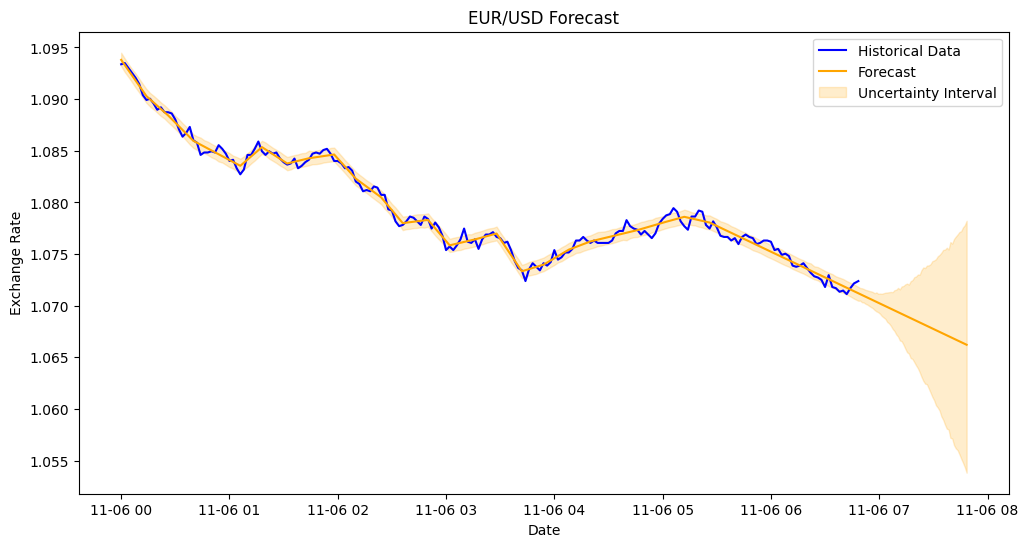

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df['ds'], df['y'], label='Historical Data', color='blue')

plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='orange')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='orange', alpha=0.2, label='Uncertainty Interval')

plt.title('EUR/USD Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


# Smoothing

In [5]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import matplotlib.pyplot as plt

sales_data = df.copy()
sales_data.set_index('ds',inplace=True)

## 1. Simple Exponential Smoothing (SES)


C:\Users\Slmss\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


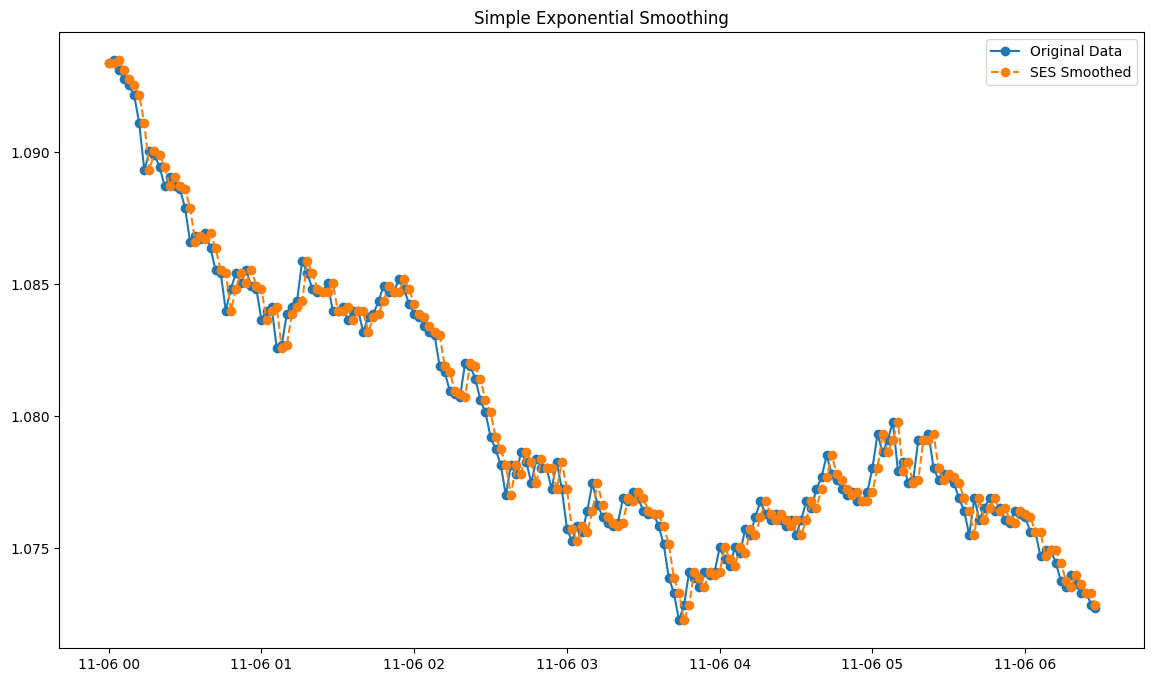

In [12]:
plt.figure(figsize=(14, 8))

a =1

ses_model = SimpleExpSmoothing(sales_data).fit(smoothing_level=a, optimized=False)
ses_smoothed = ses_model.fittedvalues

plt.plot(sales_data, label='Original Data', marker='o')
plt.plot(ses_smoothed, label='SES Smoothed', linestyle='--', marker='o')
plt.title('Simple Exponential Smoothing')
plt.legend()

## 2. Double Exponential Smoothing (DES) - Holt's Linear Trend Model

C:\Users\Slmss\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


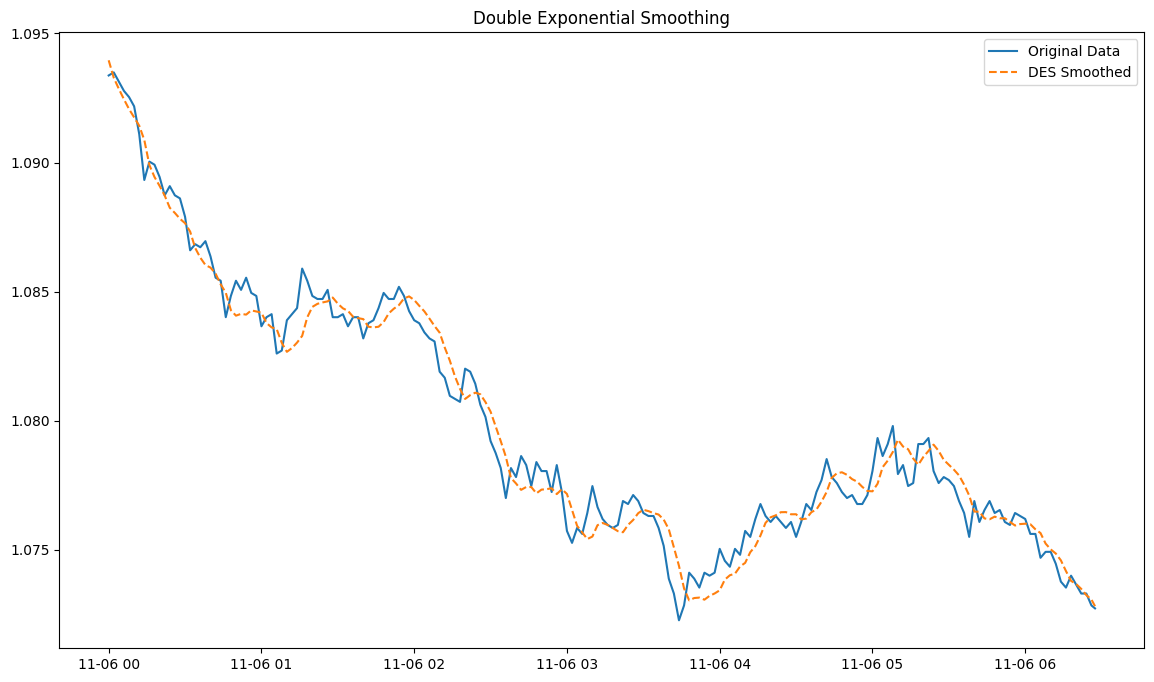

In [14]:
plt.figure(figsize=(14, 8))

des_model = ExponentialSmoothing(sales_data, trend="add").fit(smoothing_level=0.3, smoothing_slope=0.1, optimized=False)
des_smoothed = des_model.fittedvalues

# plt.subplot(3, 1, 2)
plt.plot(sales_data, label='Original Data')
plt.plot(des_smoothed, label='DES Smoothed', linestyle='--')
plt.title('Double Exponential Smoothing')
plt.legend()

## 3. Triple Exponential Smoothing (TES) - Holt-Winters Model with Additive Seasonality

C:\Users\Slmss\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


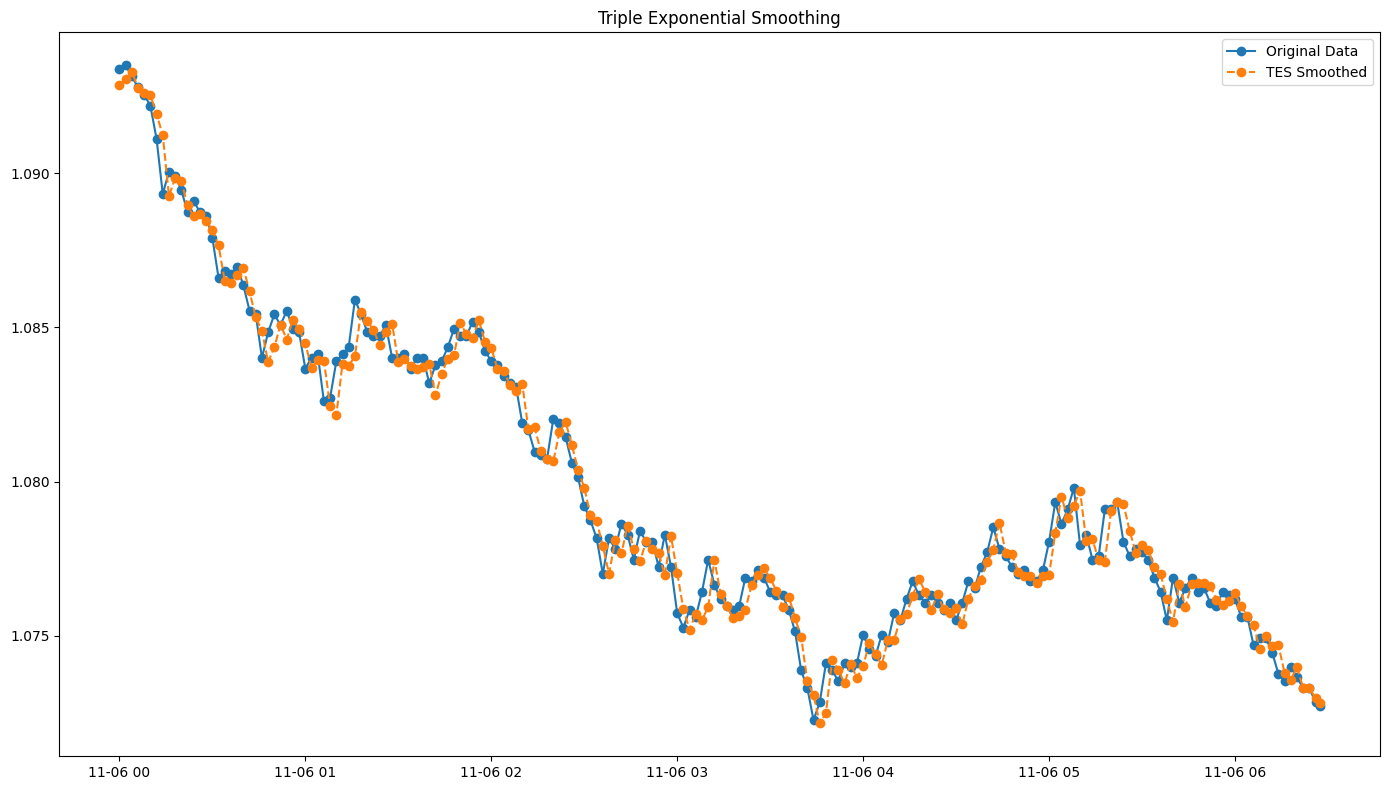

In [8]:
plt.figure(figsize=(14, 8))

tes_model = ExponentialSmoothing(sales_data, trend="add", seasonal="add", seasonal_periods=12).fit()
tes_smoothed = tes_model.fittedvalues

# plt.subplot(3, 1, 3)
plt.plot(sales_data, label='Original Data', marker='o')
plt.plot(tes_smoothed, label='TES Smoothed', linestyle='--', marker='o')
plt.title('Triple Exponential Smoothing')
plt.legend()

# Display plot
plt.tight_layout()
plt.show()

<Axes: xlabel='Datetime'>

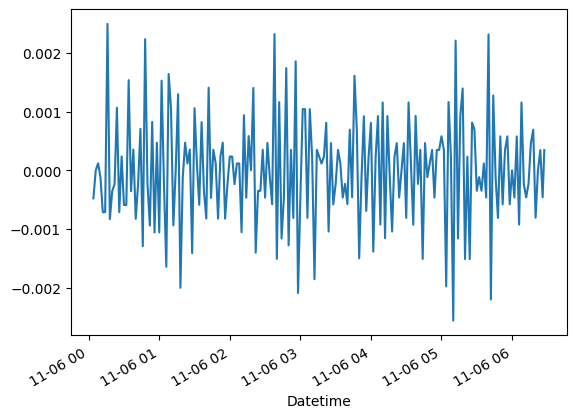

In [19]:
data.Open.diff().diff().plot()

In [29]:
from statsmodels.tsa.stattools import adfuller

temp = data.Open.diff().dropna()
adfuller(temp)


(-7.4801049769671915,
 4.797398292352854e-11,
 3,
 190,
 {'1%': -3.4652439354133255,
  '5%': -2.8768752281673717,
  '10%': -2.574944653739612},
 -2115.2375256323344)

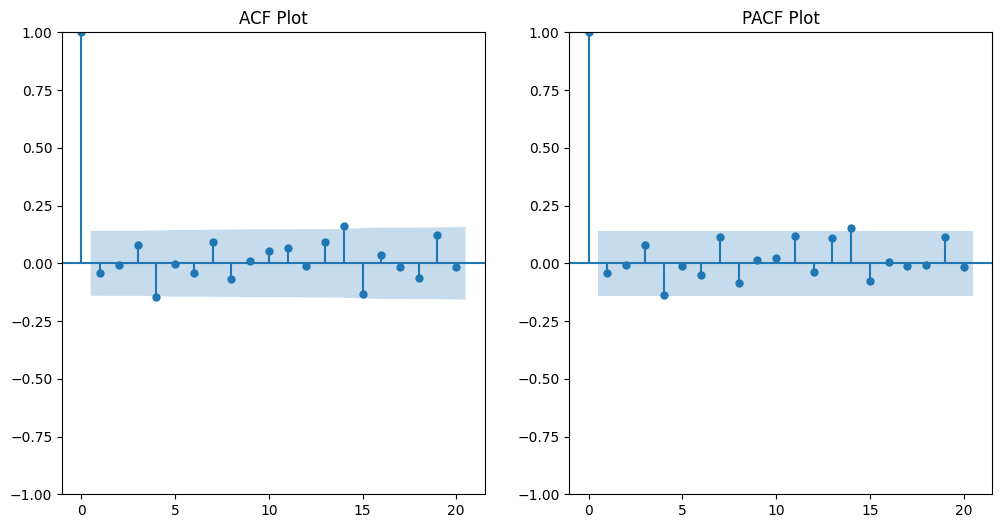

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(temp, ax=plt.gca(), lags=20)  # ACF plot after differencing
plt.title("ACF Plot")

plt.subplot(1, 2, 2)
plot_pacf(temp, ax=plt.gca(), lags=20)  # PACF plot after differencing
plt.title("PACF Plot")

plt.show()


## 

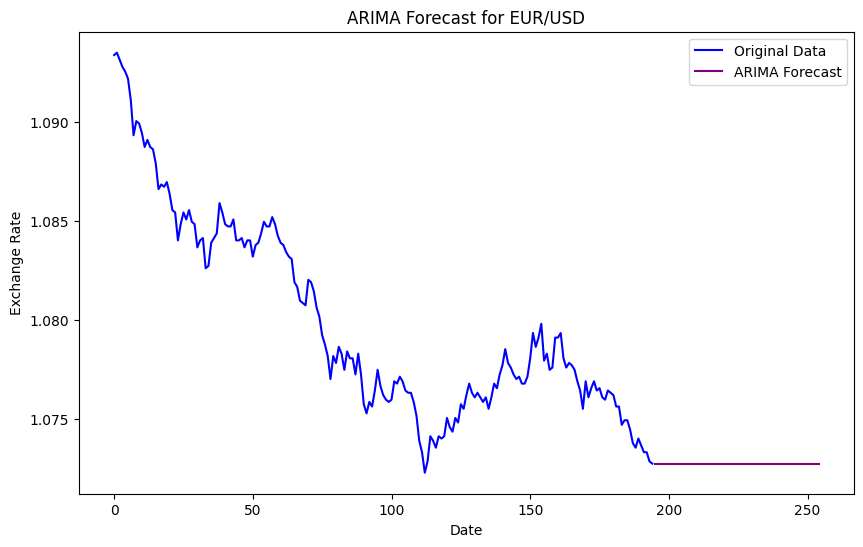

In [31]:
from statsmodels.tsa.arima.model import ARIMA



# Apply ARIMA model (ARIMA(p, d, q))
arima_model = ARIMA(df['y'], order=(1, 1, 1))
arima_result = arima_model.fit()

# Forecast with ARIMA
forecast_arima = arima_result.forecast(steps=60)

# Plot ARIMA
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['y'], label='Original Data', color='blue')
plt.plot(forecast_arima.index, forecast_arima, label='ARIMA Forecast', color='purple')
plt.title('ARIMA Forecast for EUR/USD')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


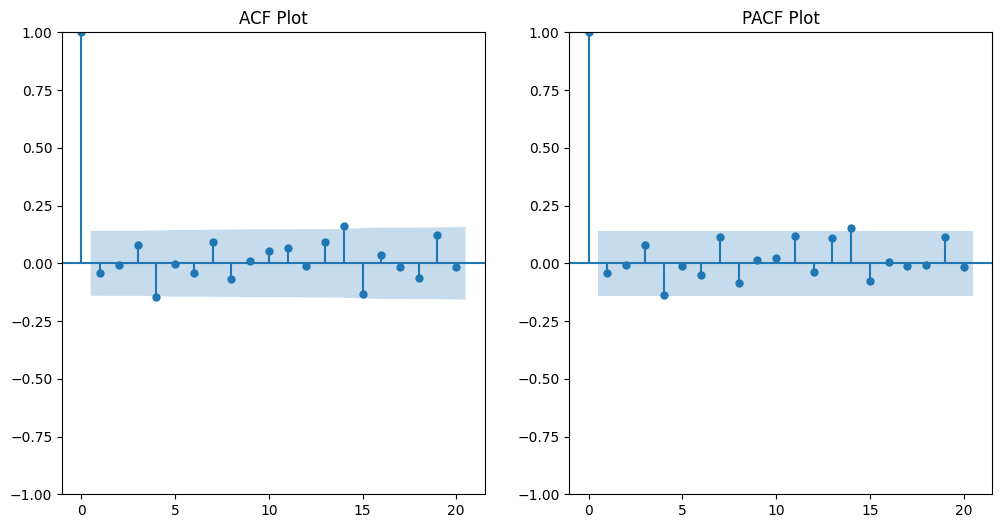

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(df['y'].diff().dropna(), ax=plt.gca(), lags=20)  # ACF plot after differencing
plt.title("ACF Plot")

plt.subplot(1, 2, 2)
plot_pacf(df['y'].diff().dropna(), ax=plt.gca(), lags=20)  # PACF plot after differencing
plt.title("PACF Plot")

plt.show()


# DL

In [38]:
from tensorflow import keras